##### ***门控循环单元(GRU)***
###### 在RNN中计算梯度，可能会导致矩阵连续乘积导致梯度消失和梯度爆炸的问题。而这种异常的梯度会在实践中产生影响。接下来考虑以下情景：<br>1. 若在一个序列的开头包含校验和，目标是在末尾判别校验和是否正确，但是由于梯度消失的问题导致模型可以已经忘了早期的存储信息。所以我们希望能有一种机制能存储重要的信息。<br>2. 若我们希望对一个网页进行情感分析，然后网页中的HTML代码显然与要情感分析的文本无关，计算这些无关的信息会污染隐变量状态导致影响后续的观测值。所以我们希望能有一种机制可以跳过此类无关词元。<br>3. 若一个序列在中途出现了逻辑中断，例如书籍切换章节。断裂的逻辑可能会导致状态的大幅度变化。所以我们希望有一种机制能重置内部状态。
##### ***门控隐状态***
###### GRU与普通的RNN的区别在于前者引入了门控机制，这意味着模型有专门的机制来确定应该何时更新隐状态，以及应该何时重置隐状态。而这种机制是可以学习的，通过训练模型，模型可以自动学习到在不同时间步应该更新隐状态和重置隐状态的时机，从而解决上述问题。
##### ***门控机制***
###### GRU的门控机制包括两个门：重置门和更新门。具体来说，两者会被$\sigma$激活函数映射到$[0,1]$之间，从而确定是否更新隐状态和重置隐状态。重置门允许我们控制“是否还想记住”，更新门则允许我们控制“挑选想记住的”。对于这两个门，它们有独立的权重系数，且计算方式与RNN中的隐变量几乎一致。
$$R_t = \sigma(X_rW_{xr} + H_{t-1}W_{hr}) + b_r,\\
Z_t = \sigma(X_tW_{xz} + H_{t-1}W_{hz}) + b_z,\\
$$
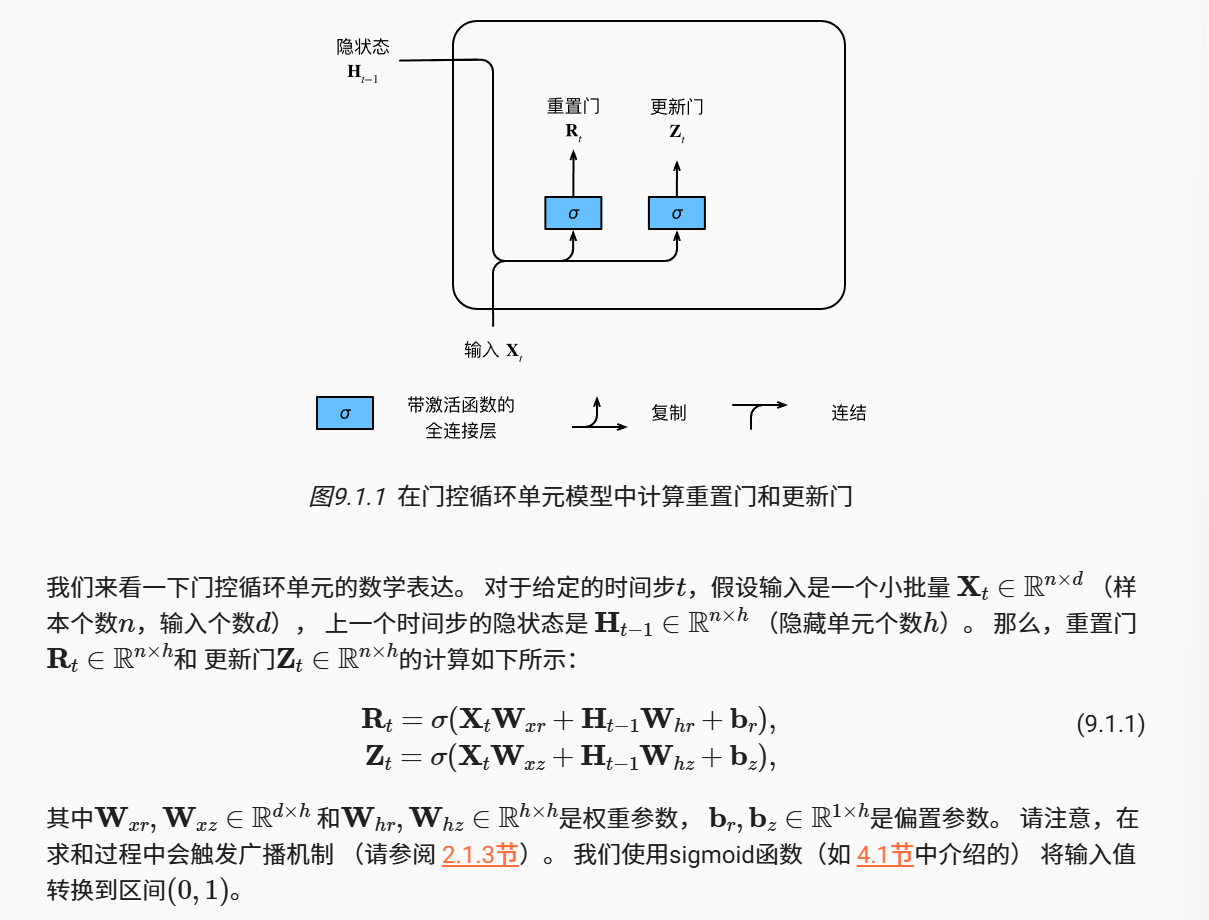
##### ***候选隐状态***
###### 为了将重置门的机制加入RNN中，我们定义了一个隐状态，使得我们可以在重置门接近1时，候选隐状态将会恢复成普通的RNN输出，而当重置门接近0时，候选隐状态将会被重置为普通的MLP输出，也就是恢复到初始状态。
$$\tilde{H_t} = tanh(X_tW_{xh} + (R_t\odot H_{t-1})W_{hh} + b_h)$$
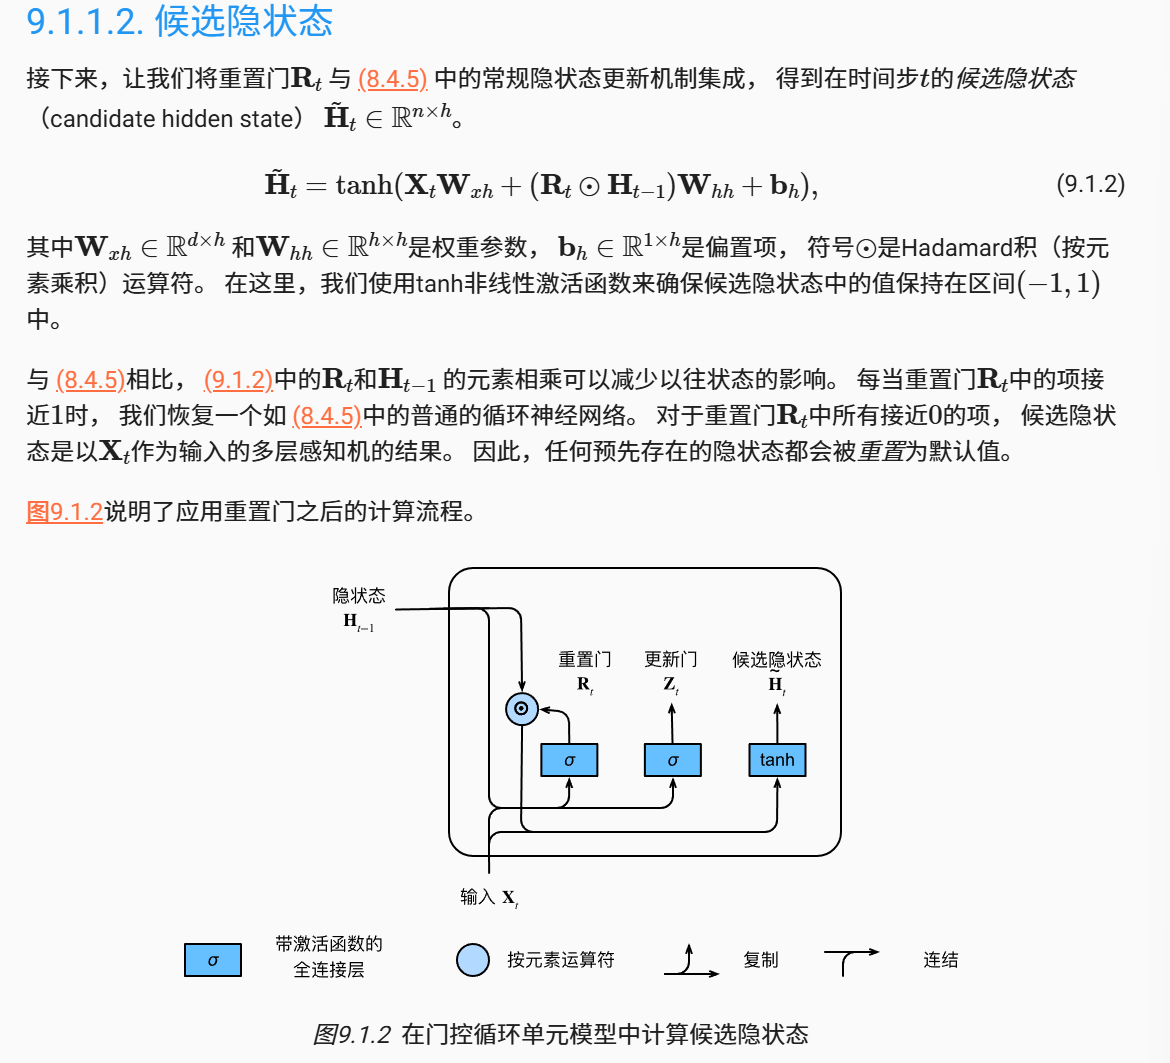
##### ***隐状态***
###### 上述候选隐状态仅仅只添加了重置门的机制，我们仍需结合更新门的效果。而更新门的效果在于控制新输入和旧记忆，也就是说可以控制当前信息是保留还是忘记，以此来实现排除无关信息的功能。
$$H_t = Z_t\odot H_{t-1} + (1-Z_t)\odot \tilde{H_t}$$
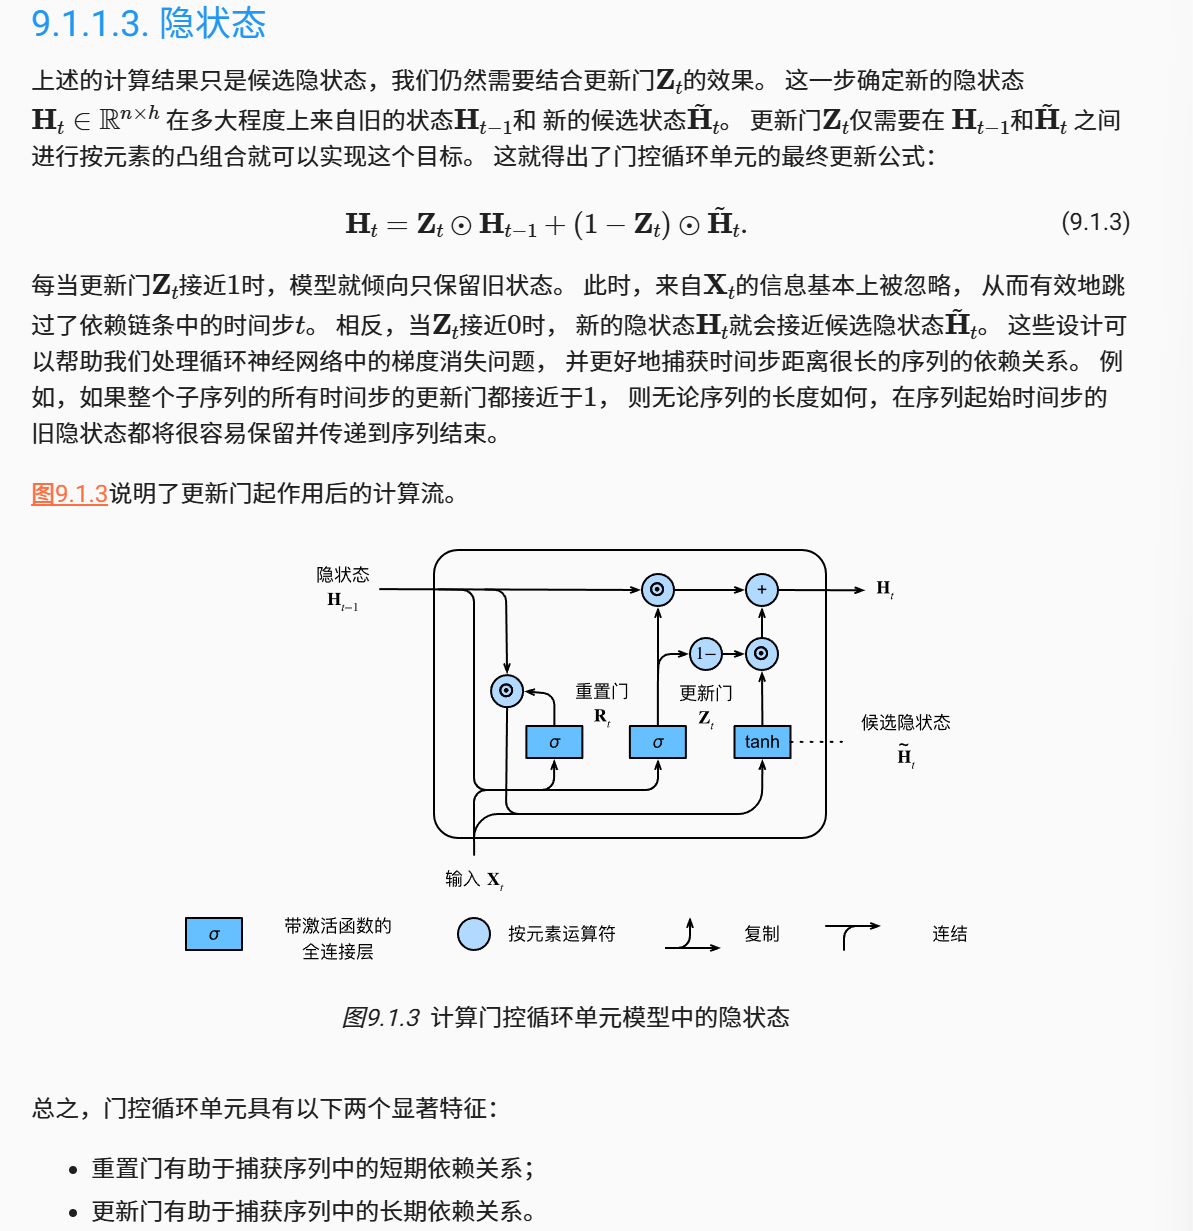

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

In [2]:
# 初始化参数
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01
    
    def three():
        return (normal((num_inputs, num_hiddens)), 
                normal((num_hiddens, num_hiddens)), 
                torch.zeros(num_hiddens, device=device))
    
    W_xz, W_hz, b_z = three() # 更新门参数
    W_xr, W_hr, b_r = three() # 重置门参数
    W_xh, W_hh, b_h = three() # 候选隐状态参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad = True
    return params

In [3]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

In [4]:
def gru(inputs, state, params):
    W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid(X @ W_xz + H @ W_hz + b_z)
        R = torch.sigmoid(X @ W_xr + H @ W_hr + b_r)
        H_tilda = torch.tanh((X @ W_xh) + ((R * H) @ W_hh) + b_h)
        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H, )


perplexity 1.1, 31582.9 tokens/sec on cpu
time traveller with a slight accession ofcheerfulness really thi
travelleryou can show black is white by argument said filby


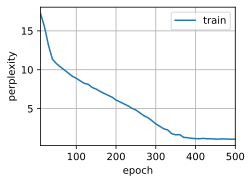

In [5]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_params,
                            init_gru_state, gru)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

perplexity 1.0, 41160.9 tokens/sec on cpu
time traveller for so it will be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


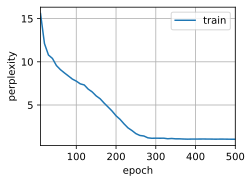

In [6]:
num_inputs = vocab_size
gru_layer = nn.GRU(num_inputs, num_hiddens)
model = d2l.RNNModel(gru_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)